# Reinforcement Learning Individual Assignment
## Text Flappy Bird - GLIE Monte-Carlo Control Agent

In [6]:
import os, sys
import gymnasium as gym
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import pickle

import text_flappy_bird_gym

## 1. Environment Setup

We use the simple state variant `TextFlappyBird-v0` which returns `(x_distance, y_distance)` — the horizontal and vertical distance from the bird to the centre of the nearest pipe gap. The action space is `Discrete(2)`: **0 = idle** (do nothing), **1 = flap**.

In [7]:
# Initialise the environment (simple state: x_dist, y_dist)
env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)

obs, info = env.reset()
print(f"Observation: {obs}")
print(f"Action space: {env.action_space}")  # Discrete(2)

Observation: (13, -5)
Action space: Discrete(2)


## 2. GLIE Monte-Carlo Control Agent

The agent maintains:
- **Q(s, a)**: action-value estimates (dictionary keyed by `(state, action)`)
- **N(s, a)**: visit counts for each state-action pair
- **$\epsilon$**: exploration rate, decayed as $\epsilon = 1/k$ (episode number) to satisfy the GLIE condition

The $\epsilon$-greedy policy selects:
- the greedy action with probability $1 - \epsilon + \epsilon/m$
- each non-greedy action with probability $\epsilon/m$

where $m$ is the number of actions.

In [ ]:
class GLIEMCAgent:
    """GLIE Monte-Carlo Control agent for Text Flappy Bird."""

    def __init__(self, n_actions: int = 2, min_epsilon: float = 0.01):
        self.n_actions = n_actions
        self.min_epsilon = min_epsilon
        # Q-values and visit counts stored as dicts for sparse state space
        self.Q = defaultdict(float)        # (state, action) -> value
        self.N = defaultdict(int)           # (state, action) -> visit count
        self.epsilon = 1.0
        self.episode_count = 0

    # policy
    def get_action(self, state: tuple) -> int:
        """Select an action using the ε-greedy policy w.r.t. current Q."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        # greedy: pick action with highest Q (break ties randomly)
        q_values = [self.Q[(state, a)] for a in range(self.n_actions)]
        max_q = max(q_values)
        best_actions = [a for a, q in enumerate(q_values) if q == max_q]
        return np.random.choice(best_actions)

    def greedy_action(self, state: tuple) -> int:
        """Purely greedy action (for evaluation)."""
        q_values = [self.Q[(state, a)] for a in range(self.n_actions)]
        max_q = max(q_values)
        best_actions = [a for a, q in enumerate(q_values) if q == max_q]
        return np.random.choice(best_actions)

    # learning
    def update(self, episode: list[tuple], gamma: float = 1.0):
        """
        Update Q from a complete episode using first-visit MC.

        Parameters
        ----------
        episode : list of (state, action, reward) tuples
        gamma   : discount factor (1.0 for undiscounted)
        """
        G = 0.0
        visited = set()
        # Walk backwards through the episode
        for t in reversed(range(len(episode))):
            state, action, reward = episode[t]
            G = gamma * G + reward

            sa = (state, action)
            # First-visit: only update the first time we see (s, a)
            if sa not in visited:
                visited.add(sa)
                self.N[sa] += 1
                # Incremental mean update: Q ← Q + (1/N)(G - Q)
                self.Q[sa] += (1.0 / self.N[sa]) * (G - self.Q[sa])

    def decay_epsilon(self):
        """GLIE epsilon decay: ε = 1/k, floored at min_epsilon."""
        self.episode_count += 1
        self.epsilon = max(self.min_epsilon, 1.0 / self.episode_count)

## 3. Training Loop

We run thousands of episodes. In each episode we:
1. Generate a full trajectory under the current $\epsilon$-greedy policy.
2. Compute returns and update $Q(s,a)$ (first-visit MC).
3. Decay $\epsilon \leftarrow 1/k$.

In [ ]:
def train(env, agent, n_episodes: int = 50_000, gamma: float = 1.0, log_every: int = 1000):
    """Train the GLIE MC agent and return training statistics."""
    reward_history = []     # total reward per episode
    avg_rewards = []        # running average (over last `log_every` episodes)
    epsilon_history = []

    for k in tqdm(range(1, n_episodes + 1), desc="Training"):
        # Generate an episode
        obs, _ = env.reset()
        state = tuple(obs)
        episode = []
        total_reward = 0.0

        done = False
        while not done:
            action = agent.get_action(state)
            next_obs, reward, done, _, info = env.step(action)
            episode.append((state, action, reward))
            total_reward += reward
            state = tuple(next_obs)

        # Update Q-values
        agent.update(episode, gamma=gamma)

        # Decay epsilon (GLIE)
        agent.decay_epsilon()

        # Logging
        reward_history.append(total_reward)
        epsilon_history.append(agent.epsilon)

        if k % log_every == 0:
            avg_r = np.mean(reward_history[-log_every:])
            avg_rewards.append(avg_r)
            print(f"Episode {k:>7d} | Avg reward (last {log_every}): {avg_r:7.2f} "
                  f"| ε: {agent.epsilon:.5f} | Q-table size: {len(agent.Q)}")

    return reward_history, avg_rewards, epsilon_history

In [ ]:
# Create agent
env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
agent = GLIEMCAgent(n_actions=env.action_space.n, min_epsilon=0.01)

TRAIN_AGENT = False
SAVE_AGENT = True

In [ ]:
save_path = os.path.join(os.path.dirname(os.getcwd()), 'results/MC/mc_agent.pkl')

# Train or load agent
if TRAIN_AGENT:
    N_EPISODES = 5_000
    reward_history, avg_rewards, epsilon_history = train(env, agent, n_episodes=N_EPISODES)

    # Save
    if SAVE_AGENT:
        with open(save_path, 'wb') as f:
            pickle.dump({'Q': dict(agent.Q), 'N': dict(agent.N),
                         'epsilon': agent.epsilon, 'episode_count': agent.episode_count}, f)
        print(f"Agent saved to {save_path}")
else:
    with open(save_path, 'rb') as f:
        data = pickle.load(f)
    agent.Q = defaultdict(float, data['Q'])
    agent.N = defaultdict(int, data['N'])
    agent.epsilon = data['epsilon']
    agent.episode_count = data['episode_count']

## 4. Training Curves

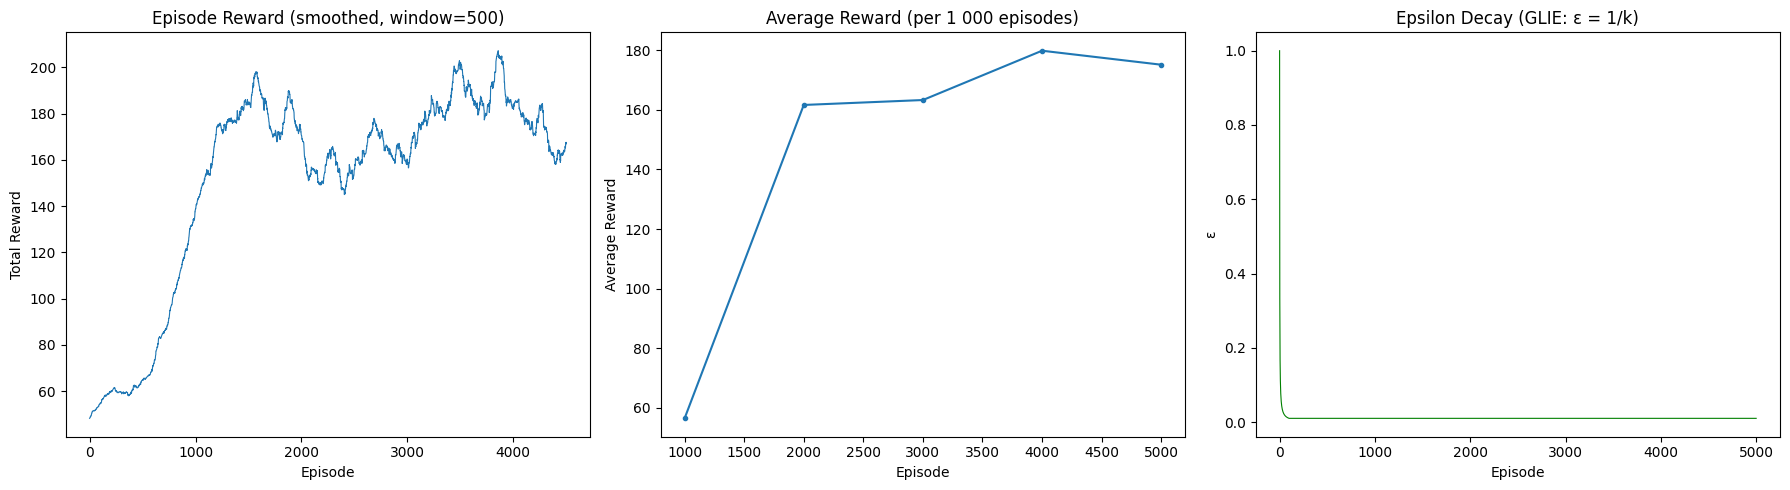

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Episode reward (smoothed)
window = 500
smoothed = np.convolve(reward_history, np.ones(window)/window, mode='valid')
axes[0].plot(smoothed, linewidth=0.8)
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Total Reward')
axes[0].set_title(f'Episode Reward (smoothed, window={window})')

# Average reward per logging interval
axes[1].plot(range(1000, N_EPISODES + 1, 1000), avg_rewards, marker='o', markersize=3)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Average Reward')
axes[1].set_title('Average Reward (per 1 000 episodes)')

# Epsilon decay
axes[2].plot(epsilon_history, linewidth=0.8, color='green')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('ε')
axes[2].set_title('Epsilon Decay (GLIE: ε = 1/k)')

plt.tight_layout()
plt.show()

## 5. Evaluation (Greedy Policy)

Run the fully trained agent (greedy, $\epsilon = 0$) for several episodes to measure its average performance.

Greedy evaluation over 1 000 episodes:
  Mean reward : 1847.94
  Std reward  : 2011.20
  Max reward  : 15698
  Min reward  : 25


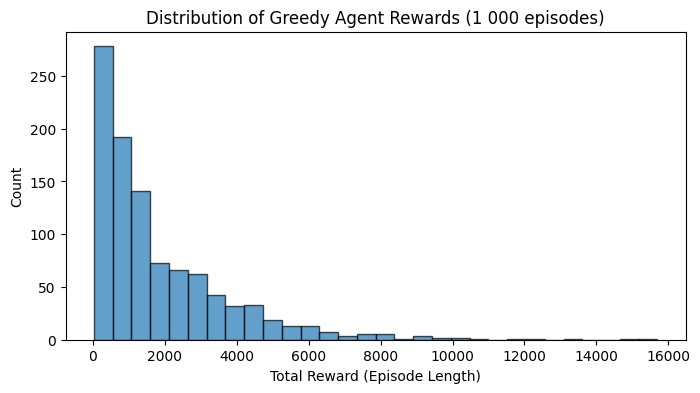

In [23]:
def evaluate(env, agent, n_episodes: int = 1000):
    """Evaluate the agent using a purely greedy policy (no exploration)."""
    total_rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        state = tuple(obs)
        total_reward = 0.0
        done = False
        while not done:
            action = agent.greedy_action(state)
            obs, reward, done, _, info = env.step(action)
            state = tuple(obs)
            total_reward += reward
        total_rewards.append(total_reward)
    return total_rewards

eval_rewards = evaluate(env, agent, n_episodes=1000)
print(f"Greedy evaluation over 1 000 episodes:")
print(f"  Mean reward : {np.mean(eval_rewards):.2f}")
print(f"  Std reward  : {np.std(eval_rewards):.2f}")
print(f"  Max reward  : {np.max(eval_rewards):.0f}")
print(f"  Min reward  : {np.min(eval_rewards):.0f}")

plt.figure(figsize=(8, 4))
plt.hist(eval_rewards, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Total Reward (Episode Length)')
plt.ylabel('Count')
plt.title('Distribution of Greedy Agent Rewards (1 000 episodes)')
plt.show()

## 6. Live Demo

Run the trained agent with the screen variant and watch it play in real-time using the scripts/MCAgent.py script.